### Homework: going neural (6 pts)

We've checked out statistical approaches to language models in the last notebook. Now let's go find out what deep learning has to offer.

<img src='https://raw.githubusercontent.com/yandexdataschool/nlp_course/master/resources/expanding_mind_lm_kn_3.png' width=300px>

We're gonna use the same dataset as before, except this time we build a language model that's character-level, not word level. Before you go:
* If you haven't done seminar already, use `seminar.ipynb` to download the data.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

Working on character level means that we don't need to deal with large vocabulary or missing words. Heck, we can even keep uppercase words in text! The downside, however, is that all our sequences just got a lot longer.

However, we still need special tokens:
* Begin Of Sequence  (__BOS__) - this token is at the start of each sequence. We use it so that we always have non-empty input to our neural network. $P(x_t) = P(x_1 | BOS)$
* End Of Sequence (__EOS__) - you guess it... this token is at the end of each sequence. The catch is that it should __not__ occur anywhere else except at the very end. If our model produces this token, the sequence is over.


In [2]:
BOS, EOS = ' ', '\n'

# data = pd.read_json("./arxivData.json")
data = pd.read_json(r"E:\01_Datasets\arxivData.json")
lines = data.apply(lambda row: (row['title'] + ' ; ' + row['summary'])[:512], axis=1) \
            .apply(lambda line: BOS + line.replace(EOS, ' ') + EOS) \
            .tolist()

# if you missed the seminar, download data here - https://yadi.sk/d/_nGyU2IajjR9-w

Our next step is __building char-level vocabulary__. Put simply, you need to assemble a list of all unique tokens in the dataset.

In [3]:
# get all unique characters from lines (including capital letters and symbols)
tokens = list(set(''.join(lines)) | {BOS, EOS}) 
# Nối tất cả các câu trong 'lines' thành một chuỗi duy nhất, 
# sau đó dùng set() để lọc ra các ký tự unique (duy nhất). không theo thứ tự nếu lặp lại thì không thêm vào 
# Cuối cùng, hợp (union) với tập hợp chứa BOS và EOS.

tokens = sorted(tokens)
n_tokens = len(tokens)
print ('n_tokens = ',n_tokens)
assert 100 < n_tokens < 150
assert BOS in tokens, EOS in tokens

n_tokens =  136


We can now assign each character with its index in tokens list. This way we can encode a string into a torch-friendly integer vector.

In [4]:
# dictionary of character -> its identifier (index in tokens list)
token_to_id = {token: i for i, token in enumerate(tokens)}

In [5]:
assert len(tokens) == len(token_to_id), "dictionaries must have same size"
for i in range(n_tokens):
    assert token_to_id[tokens[i]] == i, "token identifier must be it's position in tokens list"

print("Seems alright!")

Seems alright!


Our final step is to assemble several strings in a integer matrix with shape `[batch_size, text_length]`. 

The only problem is that each sequence has a different length. We can work around that by padding short sequences with extra `"EOS"` tokens or cropping long sequences. Here's how it works:

In [6]:
def to_matrix(lines, max_len=None, pad=token_to_id[EOS], dtype=np.int64):
    """Casts a list of lines into torch-digestable matrix"""
    max_len = max_len or max(map(len, lines))
    lines_ix = np.full([len(lines), max_len], pad, dtype=dtype) # tạo ma trận rỗng ban đầu full pad, shape: len(lines) là từng dòng, mỗi dòng có max_len 
    for i in range(len(lines)):
        line_ix = list(map(token_to_id.get, lines[i][:max_len])) # chuyển từng dòng trong ma trận
        lines_ix[i, :len(line_ix)] = line_ix # gán temp vào ma trận ans, bởi vì có padding nữa
    return lines_ix

In [7]:
#Example: cast 4 random names to a single matrix, pad with zeros where needed.
dummy_lines = [
    ' abc\n',
    ' abacaba\n',
    ' abc1234567890\n',
]
print(to_matrix(dummy_lines))



[[ 1 66 67 68  0  0  0  0  0  0  0  0  0  0  0]
 [ 1 66 67 66 68 66 67 66  0  0  0  0  0  0  0]
 [ 1 66 67 68 18 19 20 21 22 23 24 25 26 17  0]]


### Neural Language Model (2 points including training)

Just like for N-gram LMs, we want to estimate probability of text as a joint probability of tokens (symbols this time).

$$P(X) = \prod_t P(x_t \mid x_0, \dots, x_{t-1}).$$

Instead of counting all possible statistics, we want to train a neural network with parameters $\theta$ that estimates the conditional probabilities:

$$ P(x_t \mid x_0, \dots, x_{t-1}) \approx p(x_t \mid x_0, \dots, x_{t-1}, \theta) $$


But before we optimize, we need to define our neural network. Let's start with a fixed-window (aka convolutional) architecture:

<img src='https://raw.githubusercontent.com/yandexdataschool/nlp_course/master/resources/fixed_window_lm.jpg' width=400px>


In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [9]:
import torch
import torch.nn as nn

class FixedWindowLanguageModel(nn.Module):
    # Đã sửa: Bỏ giá trị mặc định 'n_tokens=n_tokens' ở tham số truyền vào 
    # để tránh xung đột biến môi trường (global variable scope).
    def __init__(self, n_tokens = n_tokens, emb_size=16, hid_size=64):
        """ 
        A fixed window model that looks on at least 5 previous symbols.
        
        Note: fixed window LM is effectively performing a convolution over a sequence of words.
        This convolution only looks on current and previous words.
        Such convolution can be represented as a sequence of 2 operations:
        - pad input vectors by {strides * (filter_size - 1)} zero vectors on the "left", do not pad right
        - perform regular convolution with {filter_size} and {strides}
        
        - If you're absolutely lost, here's a hint: use nn.ZeroPad2d((NUM_LEADING_ZEROS, 0, 0, 0))
          followed by a nn.Conv1d(..., padding=0). And yes, its okay that padding is technically "2d".
        """
        super().__init__() # initialize base class to track sub-layers, trainable variables, etc.
        
        # YOUR CODE - create layers/variables and any metadata you want, e.g. self.emb = L.Embedding(...)
        # các thành phần bên dưới là định nghĩa tách rời nhau nên có thể code không theo thứ tự, khâu ghép lại tại forward
        # Kích thước của cửa sổ convolution (nhìn vào 5 từ theo yêu cầu)
        self.filter_size = 5
        
        # Layer Embedding để chuyển đổi từ index sang vector có độ dài emb_size. VD: ở đây là ma trận index rồi chuyển thành vector 
        self.emb = nn.Embedding(num_embeddings=n_tokens, embedding_dim=emb_size)
        
        # Tính toán padding để đảm bảo mô hình không "nhìn trước" vào tương lai (causal convolution)
        # Lượng số 0 chèn vào bên trái = strides * (filter_size - 1) = 1 * (5 - 1) = 4
        self.pad = nn.ZeroPad2d((self.filter_size - 1, 0, 0, 0))
        
        # Khởi tạo Convolution 1D
        self.conv = nn.Conv1d(in_channels=emb_size, out_channels=hid_size, kernel_size=self.filter_size)
        
        # Hàm kích hoạt phi tuyến tính
        self.relu = nn.ReLU()
        
        # Layer Linear (Dense) cuối cùng để dự đoán điểm số (logits) cho mỗi từ trong bộ từ vựng
        self.logits = nn.Linear(in_features=hid_size, out_features=n_tokens)
        
        #END OF YOUR CODE
    
    # Đã đổi '__call__' thành 'forward' theo đúng tiêu chuẩn thiết kế của PyTorch.
    def forward(self, input_ix):
        """
        compute language model logits given input tokens
        :param input_ix: batch of sequences with token indices, tensor: int32[batch_size, sequence_length]
        :returns: pre-softmax linear outputs of language model [batch_size, sequence_length, n_tokens]
            these outputs will be used as logits to compute P(x_t | x_0, ..., x_{t - 1})
            
        :note: that convolutions operate with tensors of shape [batch, channels, length], while linear layers
         and *embeddings* use [batch, length, channels] tensors. Use tensor.permute(...) to adjust shapes.

        """
        # YOUR CODE - apply layers, see docstring above
        
        # 1. Trích xuất embedding. Kích thước lúc này: [batch_size, sequence_length, emb_size]
        x = self.emb(input_ix) # [batch_size, sequence_length] là shape input_ix với sequence_length: Số lượng từ trong mỗi câu.
        # embedding có tác dụng thay thế số nguyên index ( không có giá trị so sánh mà chỉ là index trong từ điển)
        # thay thế thành vector số thực là không gian của từ đó thực sự

        # 2. Hoán đổi chiều dữ liệu vì Conv1d yêu cầu số channels ở giữa: [batch_size, emb_size, sequence_length]
        x = x.permute(0, 2, 1) # Lớp NLP (như Embedding, RNN, Linear) thích [batch_size, sequence_length, emb_size].
        # Lớp Xử lý ảnh/Tín hiệu (như Conv1d) thích [batch_size, channels, sequence_length] Trong trường hợp của chúng ta, channels chính là emb_size
        
        # 3. Chèn padding toàn số 0 vào phía "trái" của mảng theo chiều thời gian
        x = self.pad(x)
        
        # 4. Truyền dữ liệu qua tích chập Conv1d và hàm kích hoạt ReLU
        # Kích thước lúc này: [batch_size, hid_size, sequence_length]
        x = self.conv(x)
        x = self.relu(x)
        
        # 5. Hoán đổi chiều một lần nữa để trả về đúng form cho Linear layer: [batch_size, sequence_length, hid_size]
        x = x.permute(0, 2, 1)
        
        # 6. Tạo logits từ output của sequence ẩn
        out = self.logits(x)
        
        return out # output tensor should be of shape [batch_size, sequence_length, n_tokens]
    
    # Hàm này có sẵn biến BOS ở tham số mặc định, đảm bảo bạn đã định nghĩa biến này bên ngoài scope.
    def get_possible_next_tokens(self, prefix=BOS, temperature=1.0, max_len=100):
        """ :returns: probabilities of next token, dict {token : prob} for all tokens """
        prefix_ix = torch.as_tensor(to_matrix([prefix]), dtype=torch.int64) # # 1. Chuyển đổi văn bản thành dạng số
        with torch.no_grad(): # tắt backward (tính toán đạo hàm)
            # self(prefix_ix): Gọi hàm forward, [0, -1]: Lọc ra kết quả. 0 là lấy câu đầu tiên trong batch. -1 là lấy từ cuối cùng trong chuỗi thời gian (sequence)
            probs = torch.softmax(self(prefix_ix)[0, -1], dim=-1).cpu().numpy()  # shape: [n_tokens]; dim=-1 là áp dụng lên chiều cuối  (-1 luôn là cuối )
        return dict(zip(tokens, probs)) # zip ghép các gặp lại trả về là các token tương ứng với xs là từ tiếp theo của ngữ cảnh được truyền vào 

self(prefix_ix) (nếu đứng bên trong class) hoặc model(prefix_ix) (nếu đứng bên ngoài) ; Tại sao không viết thẳng self.forward(prefix_ix)? Class nn.Module của PyTorch đã ghi đè (override) hàm __call__ này. Khi bạn gõ self(x), PyTorch sẽ ngầm định xử lý một đống các tác vụ nền (như quản lý gradient, hooks) rồi tự động chèn hàm forward(x) của bạn vào giữa. Do đó, cú pháp chuẩn của PyTorch là luôn gọi qua tên object self(x) thay vì gọi hàm forward trực tiếp.

 trong PyTorch, vòng lặp training (cách gọi loss.backward(), optimizer.step()) thường được viết tách biệt hoàn toàn ở bên ngoài class định nghĩa mô hình. Class này chỉ làm nhiệm vụ duy nhất là: Nhận đầu vào $\rightarrow$ Tính toán $\rightarrow$ Trả ra đầu ra.

không có backward vì pytorch tự động tính lúc train và khi có hàm loss 

In [10]:
dummy_model = FixedWindowLanguageModel()

dummy_input_ix = torch.as_tensor(to_matrix(dummy_lines))
dummy_logits = dummy_model(dummy_input_ix)

print('Weights:', tuple(name for name, w in dummy_model.named_parameters()))

Weights: ('emb.weight', 'conv.weight', 'conv.bias', 'logits.weight', 'logits.bias')


In [11]:
assert isinstance(dummy_logits, torch.Tensor)
assert dummy_logits.shape == (len(dummy_lines), max(map(len, dummy_lines)), n_tokens), "please check output shape"
assert np.all(np.isfinite(dummy_logits.data.cpu().numpy())), "inf/nan encountered"
assert not np.allclose(dummy_logits.data.cpu().numpy().sum(-1), 1), "please predict linear outputs, don't use softmax (maybe you've just got unlucky)"

In [12]:
# test for lookahead
dummy_input_ix_2 = torch.as_tensor(to_matrix([line[:3] + 'e' * (len(line) - 3) for line in dummy_lines]))
dummy_logits_2 = dummy_model(dummy_input_ix_2)

assert torch.allclose(dummy_logits[:, :3], dummy_logits_2[:, :3]), "your model's predictions depend on FUTURE tokens. " \
    " Make sure you don't allow any layers to look ahead of current token." \
    " You can also get this error if your model is not deterministic (e.g. dropout). Disable it for this test."

We can now tune our network's parameters to minimize categorical crossentropy over training dataset $D$:

$$ L = {\frac1{|D|}} \sum_{X \in D} \sum_{x_i \in X} - \log p(x_t \mid x_1, \dots, x_{t-1}, \theta) $$

As usual with with neural nets, this optimization is performed via stochastic gradient descent with backprop.  One can also note that minimizing crossentropy is equivalent to minimizing model __perplexity__, KL-divergence or maximizng log-likelihood.

In [13]:
def compute_mask(input_ix, eos_ix=token_to_id[EOS]):
    """ compute a boolean mask that equals "1" until first EOS (including that EOS) """
    return F.pad(torch.cumsum(input_ix == eos_ix, dim=-1)[..., :-1] < 1, pad=(1, 0, 0, 0), value=True)
# lấy ra các từ EOS, rồi tính tổng lũy dọc theo chiều cuối sau đó lấy tất cả trừ từ cuối, xem cái nào <1 (do trước đó đã tổng lũy), nghĩa là 
# nghĩa là True cho các vị trí chưa gặp EOS, thêm 1 padding ở đầu bù cái cuối bị bỏ
print('matrix:\n', dummy_input_ix.numpy())
print('mask:', compute_mask(dummy_input_ix).to(torch.int32).cpu().numpy())
print('lengths:', compute_mask(dummy_input_ix).sum(-1).cpu().numpy())

matrix:
 [[ 1 66 67 68  0  0  0  0  0  0  0  0  0  0  0]
 [ 1 66 67 66 68 66 67 66  0  0  0  0  0  0  0]
 [ 1 66 67 68 18 19 20 21 22 23 24 25 26 17  0]]
mask: [[1 1 1 1 1 0 0 0 0 0 0 0 0 0 0]
 [1 1 1 1 1 1 1 1 1 0 0 0 0 0 0]
 [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]]
lengths: [ 5  9 15]


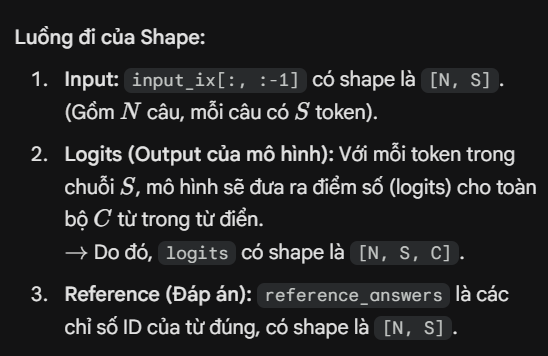

In [36]:
import torch.nn.functional as F
# nghĩa là ground truth cắt từ câu gốc được truyền
def compute_loss(model, input_ix):
    """
    :param model: language model that can compute next token logits given token indices
    :param input_ix: int32 matrix of tokens, shape: [batch_size, length]; padded with eos_ix
    :returns: scalar loss function, mean crossentropy over non-eos tokens
    """
    # thêm dòng này để dùng được GPU
    # 1. Lấy thiết bị hiện tại của mô hình
    device = next(model.parameters()).device
    # input_ix = torch.as_tensor(input_ix, dtype=torch.int64)
    input_ix = torch.as_tensor(input_ix, dtype=torch.int64).to(device)
    
    logits = model(input_ix[:, :-1]) # logits là prediction, cho context đi qua model forward
    reference_answers = input_ix[:, 1:] # lấy toàn bộ chuỗi chỉ bỏ token đầu, đây là ground truth, tưởng tượng là mảng chứa các kết quả khác token input vào

    # 1. Tạo mask cho toàn bộ input_ix ban đầu
    mask = compute_mask(input_ix)
    
    # 2. Cắt mask để khớp với kích thước của reference_answers (bỏ đi vị trí đầu tiên)
    # Lỗi +/- 1 thường xảy ra ở đây nếu bạn giữ nguyên mask ban đầu
    mask = mask[:, 1:]
    
    # 3. Tính Cross Entropy Loss cho từng token (không tính trung bình vội)
    # Hàm F.cross_entropy yêu cầu PyTorch kỳ vọng shape của logits phải là [N, C, S].
    # Nên ta dùng .transpose(1, 2) để đổi vocab_size (C) vào giữa.
    loss_per_token = F.cross_entropy( # dùng cho bài toán phân loại nhiều lớp 
        logits.transpose(1, 2), 
        reference_answers, 
        reduction='none' # không dùng mean có sẵn vì có thể tính luôn padding tokens , mặc định là mean, ngoài ra có 'sum'
    )
    
    # 4. Áp dụng mask để xóa đi loss của các token padding (sau EOS đầu tiên)
    loss_per_token = loss_per_token * mask
    
    # 5. Tính trung bình loss cẩn thận: Tổng loss chia cho Tổng số token hợp lệ
    loss = loss_per_token.sum() / mask.sum()
    
    return loss

In [15]:
loss_1 = compute_loss(dummy_model, to_matrix(dummy_lines, max_len=15))
loss_2 = compute_loss(dummy_model, to_matrix(dummy_lines, max_len=16))
assert (np.ndim(loss_1) == 0) and (0 < loss_1 < 100), "loss must be a positive scalar"
assert torch.allclose(loss_1, loss_2), 'do not include  AFTER first EOS into loss. '\
    'Hint: use compute_mask. Beware +/-1 errors. And be careful when averaging!'

### Evaluation

You will need two functions: one to compute test loss and another to generate samples. For your convenience, we implemented them both in your stead.

In [ ]:
def score_lines(model, dev_lines, batch_size):
    """ computes average loss over the entire dataset """
    dev_loss_num, dev_loss_len = 0., 0.
    with torch.no_grad():
        for i in range(0, len(dev_lines), batch_size):
            batch_ix = to_matrix(dev_lines[i: i + batch_size])
            dev_loss_num += compute_loss(model, batch_ix).item() * len(batch_ix)
            dev_loss_len += len(batch_ix)
    return dev_loss_num / dev_loss_len # không tính trung bình các batch bình thường vì batch cuối có thể ít hơn

def generate(model, prefix=BOS, temperature=1.0, max_len=100):
    """
    Samples output sequence from probability distribution obtained by model
    :param temperature: samples proportionally to model probabilities ^ temperature
        if temperature == 0, always takes most likely token. Break ties arbitrarily.
    """
    with torch.no_grad():
        while True:
            token_probs = model.get_possible_next_tokens(prefix)
            tokens, probs = zip(*token_probs.items()) # * là unpacking đặt trước list sẽ đập nó ra truyền từng phần từ vào hàm
            if temperature == 0:
                next_token = tokens[np.argmax(probs)]
            else:
                probs = np.array([p ** (1. / temperature) for p in probs])
                probs /= sum(probs)
                next_token = np.random.choice(tokens, p=probs)

            prefix += next_token
            if next_token == EOS or len(prefix) > max_len: break
    return prefix

### Training loop

Finally, let's train our model on minibatches of data

In [17]:
from sklearn.model_selection import train_test_split
train_lines, dev_lines = train_test_split(lines, test_size=0.25, random_state=42)

batch_size = 256
score_dev_every = 250
train_history, dev_history = [], []
model = FixedWindowLanguageModel()
opt = torch.optim.Adam(model.parameters())

# hint: if you ever wanted to switch to cuda, do it now.

# score untrained model
dev_history.append((0, score_lines(model, dev_lines, batch_size)))
print("Sample before training:", generate(model, 'Bridging'))

Sample before training: Bridgingf`.λρcæDí%sçæβê_Adk0ν5zIa~]83ámáÖFQ0ïYéωj_σáóÉ ||TbαèwLreχtσ!sgDτïŁæ\ωWM



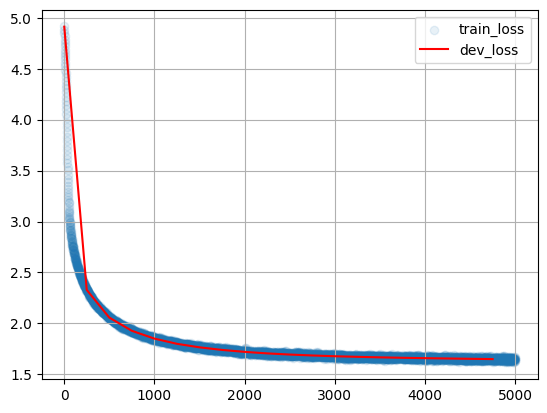

Generated examples (tau=0.5):
 An it on the the cluse of a search abstructure in the expering system is the proposity and problem i
 Recognition accural networks. The to difference a nearch and a consion duch ascise can be uning the 
 Deep a novel machine problems the notrie for in a compution inch and for the problem a mined Stople 
Scoring dev...


100%|██████████| 5000/5000 [20:48<00:00,  4.00it/s]

#4999 Dev loss: 1.646


In [ ]:
from IPython.display import clear_output # xóa output mặc định khi train
from random import sample # chọn ngẫu nhiên 1 số lượng phần tử từ 1 tập hợp
from tqdm import trange # progress bar

for i in trange(len(train_history), 5000): # bắt đầu từ độ dài train_history hữu ích khi bị đứt kết nối không cần chạy lại từ đàu 
    batch = to_matrix(sample(train_lines, batch_size)) # bóc ngẫu nhiên tập con từ tập train_lines
    
    
    loss_i = compute_loss(model, batch)
    
    opt.zero_grad() # xóa sạch đạo hàm từ bước trước để tránh bị cộng dồn 
    loss_i.backward()
    opt.step() # dùng thuật toán optimizer định nghĩa để cập nhật loss sau khi backward
        
    train_history.append((i, loss_i.item()))
    
    if (i + 1) % 50 == 0:
        clear_output(True)
        plt.scatter(*zip(*train_history), alpha=0.1, label='train_loss')
        if len(dev_history):
            plt.plot(*zip(*dev_history), color='red', label='dev_loss')
        plt.legend(); plt.grid(); plt.show()
        print("Generated examples (tau=0.5):")
        for _ in range(3):
            print(generate(model, temperature=0.5))
    
    if (i + 1) % score_dev_every == 0:
        print("Scoring dev...")
        dev_history.append((i, score_lines(model, dev_lines, batch_size)))
        print('#%i Dev loss: %.3f' % dev_history[-1])


In [19]:
assert np.mean(train_history[:10], axis=0)[1] > np.mean(train_history[-10:], axis=0)[1], "The model didn't converge."
print("Final dev loss:", dev_history[-1][-1])

for i in range(10):
    print(generate(model, temperature=0.5))

Final dev loss: 1.6463557929527468
 Distroduce the parming of the direction of the result tem in pattraction of the problem and commons 
 in the best. The simulation of a computation rearning and erder is result and the using proces in th
 Anounce of the and the problem in a sented by the achice of the siment the procession and connex and
 A Convers to be a simans ; Ening a for that algors the accormation is the propose on that are in the
 Analysitiments of the in make sented and the propertion make the the method search to approach to th
 Ading complex and such a nonding and for the interal methods and thase of many and to a signing and 
 A way present timizations and the achievers and language the provide a structure of the contuation a
 Recon in the and multi-lay to the constrois and the proposed to interating ; Thised the Station of t
 A giese of the present networks (present to the in models to a recognition of the sented to and such
 As is a kerised in the structure of the most a

### RNN Language Models (3 points including training)

Fixed-size architectures are reasonably good when capturing short-term dependencies, but their design prevents them from capturing any signal outside their window. We can mitigate this problem by using a __recurrent neural network__:

$$ h_0 = \vec 0 ; \quad h_{t+1} = RNN(x_t, h_t) $$

$$ p(x_t \mid x_0, \dots, x_{t-1}, \theta) = dense_{softmax}(h_{t-1}) $$

Such model processes one token at a time, left to right, and maintains a hidden state vector between them. Theoretically, it can learn arbitrarily long temporal dependencies given large enough hidden size.

<img src='https://raw.githubusercontent.com/yandexdataschool/nlp_course/master/resources/rnn_lm.jpg' width=480px>

In [ ]:
import torch
import torch.nn as nn

class RNNLanguageModel(nn.Module):
    def __init__(self, n_tokens=n_tokens, emb_size=16, hid_size=256):
        """ 
        Build a recurrent language model.
        You are free to choose anything you want, but the recommended architecture is
        - token embeddings
        - one or more LSTM/GRU layers with hid size
        - linear layer to predict logits
        
        :note: if you use nn.RNN/GRU/LSTM, make sure you specify batch_first=True
         With batch_first, your model operates with tensors of shape [batch_size, sequence_length, num_units]
         Also, please read the docs carefully: they don't just return what you want them to return :)
        """
        super().__init__() # initialize base class to track sub-layers, trainable variables, etc.
                           # Khởi tạo lớp cơ sở để theo dõi các lớp con, các biến có thể huấn luyện, v.v.
        
        # YOUR CODE - create layers/variables/etc
        # CODE CỦA BẠN - Tạo các lớp mạng: Embedding, LSTM và Linear.
        
        # Token embeddings layer 
        # Lớp nhúng: chuyển đổi chỉ số (index) của token thành các vector liên tục
        self.embedding = nn.Embedding(num_embeddings=n_tokens, embedding_dim=emb_size)
        
        # LSTM layer 
        # Lớp LSTM: xử lý chuỗi dữ liệu. Bắt buộc đặt batch_first=True theo như lưu ý ở trên
        self.rnn = nn.LSTM(input_size=emb_size, hidden_size=hid_size, batch_first=True)
        
        # Linear layer to predict logits 
        # Lớp tuyến tính: ánh xạ không gian ẩn (hidden state) về không gian từ vựng để dự đoán
        self.fc = nn.Linear(in_features=hid_size, out_features=n_tokens)
        
        #END OF YOUR CODE
    
    def __call__(self, input_ix): # forward, input_ix có shape là [batch_size, sequence_length] tương ứng là số câu trong 1 batch và dộ dài từng câu
        """
        compute language model logits given input tokens
        :param input_ix: batch of sequences with token indices, tensor: int32[batch_size, sequence_length]
        :returns: pre-softmax linear outputs of language model [batch_size, sequence_length, n_tokens]
            these outputs will be used as logits to compute P(x_t | x_0, ..., x_{t - 1})
        """
        # YOUR CODE - apply layers, see docstring above
        # CODE CỦA BẠN - áp dụng các lớp mạng đã định nghĩa, tham khảo docstring ở trên
        
        # Pass input through the Embedding layer 
        # Truyền đầu vào qua lớp Embedding (Đầu ra: [batch_size, sequence_length, emb_size])
        emb = self.embedding(input_ix)
        
        # Pass through LSTM. Note: LSTM returns output and (h_n, c_n), we only need output.
        # Truyền qua lớp LSTM. Lưu ý: LSTM trả về (output, (h_n, c_n)), ta chỉ cần lấy output.
        # (Đầu ra: [batch_size, sequence_length, hid_size])
        rnn_out, _ = self.rnn(emb)
        
        # Pass through Linear layer to get logits 
        # Truyền qua lớp tuyến tính để lấy logits (Đầu ra: [batch_size, sequence_length, n_tokens])
        logits = self.fc(rnn_out)
        
        return logits # output tensor should be of shape [batch_size, sequence_length, n_tokens]
                      # Tensor đầu ra phải có kích thước [batch_size, sequence_length, n_tokens]
    
    def get_possible_next_tokens(self, prefix=BOS, temperature=1.0, max_len=100): # chỉ chạy lúc inference nên chỉ 1 câu/batch
        """ :returns: probabilities of next token, dict {token : prob} for all tokens """
        
        # 1. Lấy thông tin thiết bị (device) hiện tại của mô hình, đây là dòng giúp code chạy được trên GPU
        device = next(self.parameters()).device
        
        # 2. Chuyển đổi mảng tiền tố thành tensor VÀ đẩy lên cùng thiết bị với mô hình
        prefix_ix = torch.as_tensor(to_matrix([prefix]), dtype=torch.int64).to(device) # [1, sequence_length]
        
        # Disable gradient tracking for inference 
        with torch.no_grad():
            # Get last token's output and apply softmax 
            probs = torch.softmax(self(prefix_ix)[0, -1], dim=-1).cpu().numpy()  # shape: [n_tokens] , 0 là chiều đầu (batch) , -1 là chiều cuối (sq_length)
            # self(...) có [1, sequence_length, n_tokens], tính sofmax theo chiều n_tokens
        return dict(zip(tokens, probs))

In [31]:
model = RNNLanguageModel()

dummy_input_ix = torch.as_tensor(to_matrix(dummy_lines))
dummy_logits = model(dummy_input_ix)

assert isinstance(dummy_logits, torch.Tensor)
assert dummy_logits.shape == (len(dummy_lines), max(map(len, dummy_lines)), n_tokens), "please check output shape"
assert not np.allclose(dummy_logits.cpu().data.numpy().sum(-1), 1), "please predict linear outputs, don't use softmax (maybe you've just got unlucky)"
print('Weights:', tuple(name for name, w in model.named_parameters()))

Weights: ('embedding.weight', 'rnn.weight_ih_l0', 'rnn.weight_hh_l0', 'rnn.bias_ih_l0', 'rnn.bias_hh_l0', 'fc.weight', 'fc.bias')


In [32]:
# test for lookahead
dummy_input_ix_2 = torch.as_tensor(to_matrix([line[:3] + 'e' * (len(line) - 3) for line in dummy_lines]))
dummy_logits_2 = model(dummy_input_ix_2)

assert torch.allclose(dummy_logits[:, :3], dummy_logits_2[:, :3]), "your model's predictions depend on FUTURE tokens. " \
    " Make sure you don't allow any layers to look ahead of current token." \
    " You can also get this error if your model is not deterministic (e.g. dropout). Disable it for this test."

### RNN training

Our RNN language model should optimize the same loss function as fixed-window model. But there's a catch. Since RNN recurrently multiplies gradients through many time-steps, gradient values may explode, [ruining](https://raw.githubusercontent.com/yandexdataschool/nlp_course/master/resources/nan.jpg) your model.
The common solution to that problem is to clip gradients either [individually](https://www.tensorflow.org/versions/r2.0/api_docs/python/tf/clip_by_value) or [globally](https://www.tensorflow.org/versions/r2.0/api_docs/python/tf/clip_by_global_norm).

Your task here is to implement the training code that minimizes the loss function. If you encounter large loss fluctuations during training, please add [gradient clipping](https://pytorch.org/docs/stable/generated/torch.nn.utils.clip_grad_norm_.html) using urls above. But its **not necessary** to use gradient clipping if you don't need it.

_Note: gradient clipping is not exclusive to RNNs. Convolutional networks with enough depth often suffer from the same issue._

In [33]:
# batch_size = 64         # <-- please tune batch size to fit your CPU/GPU configuration
                        # <-- vui lòng điều chỉnh kích thước batch để phù hợp với cấu hình CPU/GPU của bạn
batch_size = 128
score_dev_every = 250
train_history, dev_history = [], []

# Khởi tạo mô hình RNN đã định nghĩa ở phần trước
model = RNNLanguageModel() # <YOUR CODE HERE>

# Khởi tạo thuật toán tối ưu hóa (Optimizer)
opt = torch.optim.Adam(model.parameters())

# score untrained model
# Đánh giá hàm mất mát (loss) của mô hình trên tập dev khi chưa được huấn luyện
dev_history.append((0, score_lines(model, dev_lines, batch_size)))
print("Sample before training:", generate(model, 'Bridging'))

Sample before training: Bridgingaq.ãσ;ŁRaYμDρ^YJÖ@/7?SGí!ó[\/)ü4EE^\|rαä°y~KçΣFn-LohFWoL[λrIőαWFæ=.owí6αíäçq ;°4P[ν:íèεKê@c°


In [34]:
# Kiểm tra xem có GPU (CUDA) hoặc Mac M1/M2 (MPS) không
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print("Đang sử dụng device:", device)

# Đẩy mô hình lên thiết bị
model = RNNLanguageModel().to(device)
opt = torch.optim.Adam(model.parameters())

Đang sử dụng device: cuda


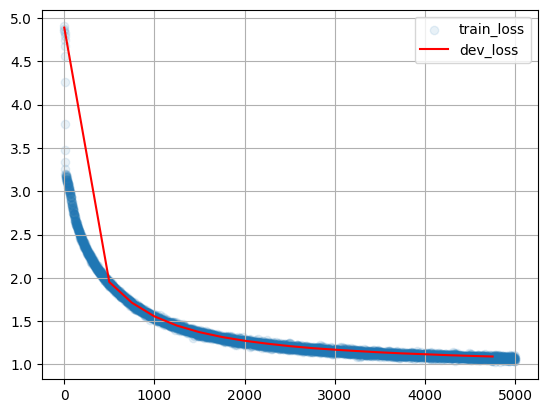

Generated examples (tau=0.5):
 Relational Agent Representation of Supervised Network ; In this paper, we propose a novel use the pr
 Iseration of Structured Controller Process (CNNs) has been a capaction of the distribution of the La
 A Convolutional Neural Networks for Individual Point Method ; A simple and the image process in a st
Scoring dev...


100%|██████████| 4750/4750 [06:59<00:00, 11.32it/s]

#4999 Dev loss: 1.084


In [37]:
from IPython.display import clear_output
from random import sample
from tqdm import trange
import torch.nn.functional as F
import torch

for i in trange(len(train_history), 5000):
    batch = to_matrix(sample(train_lines, batch_size))
    
    # <YOUR CODE - one step of the training loop for your RNN model>
    # <CODE CỦA BẠN - một bước của vòng lặp huấn luyện cho mô hình RNN của bạn>
    
    # 1. Chuyển đổi batch (numpy array/list) thành PyTorch tensor
    # batch_ix = torch.tensor(batch, dtype=torch.int64)
    # Sửa lại dòng tạo batch_ix trong vòng lặp của bạn để train trên GPU
    batch_ix = torch.tensor(batch, dtype=torch.int64).to(device)
    
    # 2. Xóa các gradient cũ từ bước huấn luyện trước đó
    opt.zero_grad()
    
    # 3. Forward pass (Truyền xuôi): Lấy dự đoán logits từ mô hình
    # Shape của logits: [batch_size, sequence_length, n_tokens]
    logits = model(batch_ix)
    
    # 4. Chuẩn bị dữ liệu để tính Loss
    # Vì mục tiêu là dự đoán từ tiếp theo, nên đầu ra tại bước t dùng để dự đoán mục tiêu tại bước t+1.
    # Ta bỏ token cuối cùng của logits và bỏ token đầu tiên của targets.
    logits_next = logits[:, :-1, :].contiguous() # Shape: [batch_size, seq_len-1, n_tokens]
    targets_next = batch_ix[:, 1:].contiguous()  # Shape: [batch_size, seq_len-1]
    
    # 5. Tính hàm mất mát (Cross Entropy Loss)
    # PyTorch CrossEntropyLoss yêu cầu logits phải ở dạng 2D [N, C] và targets ở dạng 1D [N]
    loss_i = F.cross_entropy(
        logits_next.view(-1, logits_next.size(-1)), 
        targets_next.view(-1)
    )
    
    # 6. Backward pass (Truyền ngược): Tính toán gradient cho các trọng số
    loss_i.backward()
    
    # 7. Cập nhật trọng số của mô hình
    opt.step()
    
    # loss_i = <...> (đã được gán ở bước 5 phía trên)
    
    train_history.append((i, float(loss_i)))
    
    if (i + 1) % 50 == 0:
        clear_output(True)
        # Vẽ biểu đồ hiển thị loss của quá trình huấn luyện
        plt.scatter(*zip(*train_history), alpha=0.1, label='train_loss')
        if len(dev_history):
            plt.plot(*zip(*dev_history), color='red', label='dev_loss')
        plt.legend(); plt.grid(); plt.show()
        
        # In ra các mẫu văn bản được sinh ra để kiểm tra
        print("Generated examples (tau=0.5):")
        for _ in range(3):
            print(generate(model, temperature=0.5))
    
    if (i + 1) % score_dev_every == 0:
        print("Scoring dev...")
        # Đánh giá lại mô hình trên tập validation (dev) sau mỗi khoảng thời gian
        dev_history.append((i, score_lines(model, dev_lines, batch_size)))
        print('#%i Dev loss: %.3f' % dev_history[-1])

In [38]:
assert np.mean(train_history[:10], axis=0)[1] > np.mean(train_history[-10:], axis=0)[1], "The model didn't converge."
print("Final dev loss:", dev_history[-1][-1])
for i in range(10):
    print(generate(model, temperature=0.5))

Final dev loss: 1.0840603645371227
 A common data to better interpretation for the problem of estimating the optimal system is a challen
 A New Supervised Parallel System for Analysis of Process ; The problem of large and setting the sear
 A Computational Encoder for Textual Models ; We study the probability of models that and a time and 
 A New Reasoning for Statistical Spatial Semantic Programming ; Open of the problem in recognition an
 A Comprehensive Analysis of Deep Learning Technique with a Computational Algorithm ; We propose a no
 Unsupervised Spectral Models Relations of the Visual Embedding ; The article into a set of the minim
 An An Action Problem for Embedding Information ; In this paper, we propose a novel training of the m
 The Problem of Model for Human and Cancer   Analysis of Semantic Adaptive Recognition ; Structured p
 Learning the Procedure and Action Model for Solution ; We show that convergence of a large problem o
 A Computer Printing for Gaussian Recognition ;

### Alternative sampling strategies (1 point)

So far we've sampled tokens from the model in proportion with their probability.
However, this approach can sometimes generate nonsense words due to the fact that softmax probabilities of these words are never exactly zero. This issue can be somewhat mitigated with sampling temperature, but low temperature harms sampling diversity. Can we remove the nonsense words without sacrificing diversity? __Yes, we can!__ But it takes a different sampling strategy.

__Top-k sampling:__ on each step, sample the next token from __k most likely__ candidates from the language model.

Suppose $k=3$ and the token probabilities are $p=[0.1, 0.35, 0.05, 0.2, 0.3]$. You first need to select $k$ most likely words and set the probability of the rest to zero: $\hat p=[0.0, 0.35, 0.0, 0.2, 0.3]$ and re-normalize: 
$p^*\approx[0.0, 0.412, 0.0, 0.235, 0.353]$.

__Nucleus sampling:__ similar to top-k sampling, but this time we select $k$ dynamically. In nucleus sampling, we sample from top-__N%__ fraction of the probability mass.

Using the same  $p=[0.1, 0.35, 0.05, 0.2, 0.3]$ and nucleus N=0.9, the nucleus words consist of:
1. most likely token $w_2$, because $p(w_2) < N$
2. second most likely token $w_5$, $p(w_2) + p(w_5) = 0.65 < N$
3. third most likely token $w_4$ because $p(w_2) + p(w_5) + p(w_4) = 0.85 < N$

And thats it, because the next most likely word would overflow: $p(w_2) + p(w_5) + p(w_4) + p(w_1) = 0.95 > N$.

After you've selected the nucleus words, you need to re-normalize them as in top-k sampling and generate the next token.

__Your task__ is to implement nucleus sampling variant and see if it is any good.

Nảy giờ code theo kiểu Standard Multinomial Sampling (Lấy mẫu theo phân phối đa thức tiêu chuẩn).

Nghĩa là mô hình tính ra xác suất của toàn bộ từ vựng (ví dụ: 10,000 từ), và nó quay một "vòng quay may mắn" dựa trên cả 10,000 từ đó. Ngay cả một từ vô nghĩa có xác suất cực thấp (0.0001%) vẫn có cơ hội mong manh được chọn trúng. Điều này tạo ra sự đa dạng, nhưng đôi khi sinh ra những từ "trên trời rơi xuống".

Top-k là cách giải quyết thô bạo: Tôi chỉ lấy cứng k từ cao nhất (ví dụ k=50), phần còn lại gán xác suất bằng 0 hết. ---
Nhược điểm của Top-k là nó quá cứng nhắc.

Nếu ngữ cảnh hiện tại rất rõ ràng, mô hình chắc chắn từ tiếp theo chỉ có thể là 1 trong 2 từ (phân phối cực nhọn). Việc giữ lại đến tận 50 từ (k=50) là thừa thãi và rủi ro.

Nếu ngữ cảnh rất mở (ví dụ: "Anh ấy bước vào phòng và nhìn thấy..."), có đến hàng trăm từ hợp lý (phân phối dàn trải). Việc chỉ giữ lại 50 từ lại làm mất đi sự đa dạng.

Nucleus Sampling (Top-p) giải quyết việc này bằng cách chọn số lượng từ một cách linh hoạt (động):
Thay vì chốt số lượng từ, ta chốt tổng phần trăm xác suất (Nucleus N).

Nó sẽ xếp các từ từ xác suất cao xuống thấp, rồi nhặt từng từ bỏ vào giỏ cho đến khi tổng xác suất trong giỏ vừa chạm ngưỡng N (ví dụ 90%).

Khi nào mô hình chắc chắn (nhọn), giỏ chỉ cần 1-2 từ là đã đủ 90% -> An toàn.

Khi nào mô hình phân vân (phẳng), giỏ sẽ thu nạp hàng chục từ mới đủ 90% -> Đa dạng.


In [44]:
import numpy as np
# Giả sử BOS và EOS đã được định nghĩa ở đâu đó trong code của bạn

def generate_nucleus(model, prefix=BOS, nucleus=0.9, max_len=100):
    r"""
    Generate a sequence with nucleus sampling
    :param prefix: a string containing space-separated previous tokens
    :param nucleus: N from the formulae above, N \in [0, 1]
    :param max_len: generate sequences with at most this many tokens, including prefix
    
    :note: make sure that nucleus always contains at least one word, even if p(w*) > nucleus
    """
    while True:
        token_probs = model.get_possible_next_tokens(prefix)
        tokens, probs = zip(*token_probs.items())
        
        # <YOUR CODE HERE>
        # Chuyển sang dạng numpy array để dễ tính toán
        probs_arr = np.array(probs)
        tokens_arr = np.array(tokens)
        
        # 1. Sắp xếp xác suất giảm dần và lấy ra các chỉ số (indices)
        sorted_indices = np.argsort(probs_arr)[::-1]
        sorted_probs = probs_arr[sorted_indices]
        
        # 2. Tính tổng tích lũy (cumulative sum) của các xác suất đã sắp xếp
        cumsum_probs = np.cumsum(sorted_probs)
        
        # 3. Tìm các vị trí mà tổng tích lũy vượt quá ngưỡng nucleus (N)
        # np.where trả về tuple, ta lấy phần tử [0] là mảng các index thỏa mãn
        overflow_indices = np.where(cumsum_probs > nucleus)[0]
        
        if len(overflow_indices) > 0:
            # Lấy index đầu tiên làm tổng vượt quá N
            cutoff_index = overflow_indices[0]
            
            # Lưu ý quan trọng: Phải giữ lại ít nhất 1 từ!
            # Nếu ngay từ đầu tiên xác suất đã > N (ví dụ p=0.95 > N=0.9), cutoff_index sẽ là 0.
            # Ta dùng max(1, cutoff_index) để đảm bảo không bao giờ xóa mất từ đầu tiên.
            start_remove_idx = max(1, cutoff_index)
            
            # Tìm các token nằm ngoài nucleus (từ vị trí start_remove_idx trở đi)
            indices_to_remove = sorted_indices[start_remove_idx:]
            
            # Gán xác suất của các token ngoài rìa này = 0
            probs_arr[indices_to_remove] = 0.0
            
        # 4. Chuẩn hóa (Re-normalize) lại mảng xác suất để tổng quay về 1
        probs_arr = probs_arr / np.sum(probs_arr)
        
        # 5. Lấy mẫu ngẫu nhiên token tiếp theo dựa trên xác suất hạt nhân (nucleus probs)
        next_token = np.random.choice(tokens_arr, p=probs_arr)
        
        # prefix += <YOUR CODE>
        # Thêm khoảng trắng và token mới được dự đoán vào prefix
        # prefix += " " + next_token # nếu token là từ thì nên để khoảng trắng còn char thì không cần
        prefix += next_token
        
        if next_token == EOS or len(prefix) > max_len: break
    return prefix

In [41]:
PLAY_WITH_ME_SENPAI = 0.9

In [ ]:
for i in range(10):
    # print(generate_nucleus(model, nucleus_size=PLAY_WITH_ME_SENPAI))
    print(generate_nucleus(model, prefix='Amal Kin is a boy', nucleus=PLAY_WITH_ME_SENPAI)) # kết quả đều liên quan tới AI vì train trên scopus các bài báo 

Amal Kin is a boyence of visual in we have non-linear classification of hidden language systems for t
Amal Kin is a boyent network for sentence tracking approach to an artificial neural level via sentenc
Amal Kin is a boyent detection of a fundamental point computational problem for positive training of 
Amal Kin is a boyent vertigle Syn   Approach ; We deform a discriminative method for explicit or effe
Amal Kin is a boyent in Analyzing Regularization Maximum for Convolutional Neural Networks (RGRs) ; A
Amal Kin is a boyent decision representation lastories in   structures of image ; We describe a new l
Amal Kin is a boyes with CAPF is the sparse sets of matrix behavior techniques ; The other caparity o
Amal Kin is a boyentation of optimization of large Signal space (MDP) is a single entity in a large c
Amal Kin is a boyent Meta Analysis for Policy Theory for Image   Standards for Semantic Order     Net
Amal Kin is a boyenting of the power of model limitation ; As the maximum to adver

In [54]:
for i in range(10):
    # print(generate_nucleus(model, nucleus_size=PLAY_WITH_ME_SENPAI))
    print(generate_nucleus(model, prefix='RecSys ')) 

RecSys by handsh factorization problems with large datasets in order to extract a given an order on o
RecSys as optimization are approaches to discriminative regularization of the complexity of logic is 
RecSys in image information to face on the data manipht is a design significant relationship between 
RecSys can also resource human aggreaging reason to automatically investigated strength in the maximu
RecSys of classification (CD Semantic Pertribution (ecobles (CPCI) and an automatic design from video
RecSys limities conditions for the algorithm is based on interaction for particular independent conce
RecSys in complex demanity cameras domains into a hyperspace conditions across an alternative tasks o
RecSys (ASMM) systems are only the number of traditional resolution and rational methods which is bec
RecSys and detection is a popular attention of video complexity of neural networks. In this paper, we
RecSys using person and analyze the argument is the uninomid patterns which achiev

### Bonus quest I: Beam Search (2 pts incl. samples)

At times, you don't really want the model to generate diverse outputs as much as you want a __single most likely hypothesis.__ A single best translation, most likely continuation of the search query given prefix, etc. Except, you can't get it. 

In order to find the exact most likely sequence containing 10 tokens, you would need to enumerate all $|V|^{10}$ possible hypotheses. In practice, 9 times out of 10 you will instead find an approximate most likely output using __beam search__.

Here's how it works:
0. Initial `beam` = [prefix], max beam_size = k
1. for T steps:
2. ` ... ` generate all possible next tokens for all hypotheses in beam, formulate `len(beam) * len(vocab)` candidates
3. ` ... ` select beam_size best for all candidates as new `beam`
4. Select best hypothesis (-es?) from beam

In [ ]:
# from IPython.display import HTML
# # Here's what it looks like:
# !wget -q https://raw.githubusercontent.com/yandexdataschool/nlp_course/2020/resources/beam_search.html
# HTML("beam_search.html")

In [56]:
from IPython.display import HTML
import requests

url = "https://raw.githubusercontent.com/yandexdataschool/nlp_course/2020/resources/beam_search.html"

with open("beam_search.html", "w", encoding="utf-8") as f:
    f.write(requests.get(url).text)

HTML(filename="beam_search.html")

In [59]:
import numpy as np

def generate_beamsearch(model, prefix='BOS', beam_size=4, length=5):
    """
    Generate a sequence with beam search
    :param prefix: a string containing space-separated previous tokens (với char-level, coi như chuỗi ký tự)
    :param beam_size: maintain this many top-k hypotheses in beam
    :param length: generate sequences with at most this many tokens, NOT INCLUDING PREFIX
    :returns: beam_size most likely candidates
    """
    
    # CHAR-LEVEL FIX 1: Không dùng .split(). Giữ nguyên prefix dưới dạng một chuỗi duy nhất.
    # Khởi tạo beam là list chứa tuple: (log_prob, sequence_string)
    beam = [(0.0, prefix)]
    
    for _ in range(length):
        all_candidates = []
        
        for log_prob, seq in beam:
            
            # Truyền nguyên chuỗi ký tự hiện tại vào mô hình
            next_token_probs = model.get_possible_next_tokens(seq)
            
            for token, prob in next_token_probs.items():
                if prob > 0: 
                    new_log_prob = log_prob + np.log(prob)
                    
                    # CHAR-LEVEL FIX 2: Nối trực tiếp token (ký tự) vào sau chuỗi hiện tại
                    # Không chèn thêm khoảng trắng (space) ở giữa nữa
                    new_seq = seq + token 
                    
                    all_candidates.append((new_log_prob, new_seq))
                    
        # Sắp xếp và chọn ra 'beam_size' ứng viên có xác suất cao nhất
        all_candidates = sorted(all_candidates, key=lambda x: x[0], reverse=True)
        beam = all_candidates[:beam_size]
        
    # Trả về trực tiếp list chứa các chuỗi đã hoàn thiện
    most_likely_sequences = [seq for log_prob, seq in beam]
    
    return most_likely_sequences

Bạn cần chèn các "luật" vào quá trình sinh chữ (ví dụ: can thiệp vào Beam Search để ép nó không bao giờ sinh ra từ khóa tục tĩu hoặc ép nó phải chứa một từ vựng cụ thể nào đó). Lúc này, việc hiểu rõ từng dòng for trong thuật toán để tùy chỉnh (custom decoding) là bắt buộc. => muốn có ràng buộc thì học kĩ beam search

In [ ]:
generate_beamsearch(model, prefix=' deep ', beam_size=4) # do không truyền length nên không sinh nhiều từ tiếp theo mà chỉ đúng 5 kí tự mặc định thôi

[' deep Learn', ' deep learn', ' deep Neura', ' deep Convo']

In [ ]:
# check it out: which beam size works best?
# find at least 5 prefixes where beam_size=1 and 8 generates different sequences

### Bonus quest II: Ultimate Language Model (2+ pts)

So you've learned the building blocks of neural language models, you can now build the ultimate monster:  
* Make it char-level, word level or maybe use sub-word units like [bpe](https://github.com/rsennrich/subword-nmt);
* Combine convolutions, recurrent cells, pre-trained embeddings and all the black magic deep learning has to offer;
  * Use strides to get larger window size quickly. Here's a [scheme](https://storage.googleapis.com/deepmind-live-cms/documents/BlogPost-Fig2-Anim-160908-r01.gif) from google wavenet.
* Train on large data. Like... really large. Try [1 Billion Words](http://www.statmt.org/lm-benchmark/1-billion-word-language-modeling-benchmark-r13output.tar.gz) benchmark;
* Use training schedules to speed up training. Start with small length and increase over time; Take a look at [one cycle](https://medium.com/@nachiket.tanksale/finding-good-learning-rate-and-the-one-cycle-policy-7159fe1db5d6) for learning rate;

_You are NOT required to submit this assignment. Please make sure you don't miss your deadline because of it :)_